In [1]:

import yfinance as yf
import pandas as pd
import numpy as np


In [2]:
tickers = ["KO", "JNJ", "XOM", "PG", "T"]
data = yf.download(tickers, start = "2015-01-01", end = "2026-01-01", auto_adjust= False)

print("Data Shape: " + str(data.shape))
print("Data Range: " + str(data.index[0]) + " to " + str(data.index[-1]))


[*********************100%***********************]  5 of 5 completed

Data Shape: (2766, 30)
Data Range: 2015-01-02 00:00:00 to 2025-12-31 00:00:00


In [3]:
stock = yf.Ticker("KO")
dividends = stock.dividends
print(dividends)

Date
1962-03-13 00:00:00-05:00    0.001563
1962-06-11 00:00:00-04:00    0.001563
1962-09-11 00:00:00-04:00    0.001563
1962-11-28 00:00:00-05:00    0.001563
1963-03-11 00:00:00-05:00    0.001758
                               ...   
2025-03-14 00:00:00-04:00    0.510000
2025-06-13 00:00:00-04:00    0.510000
2025-09-15 00:00:00-04:00    0.510000
2025-12-01 00:00:00-05:00    0.510000
2026-03-13 00:00:00-04:00    0.530000
Name: Dividends, Length: 257, dtype: float64


In [4]:
import datetime

In [5]:
one_year_ago = datetime.date.today() - datetime.timedelta(days=365)
print(one_year_ago)

2025-04-01


In [6]:
results = {}
for ticker in tickers:
    stock =yf.Ticker(ticker)
    dividends = stock.dividends
    annual_div = dividends[dividends.index > str(one_year_ago)].sum()
    price = stock.info["currentPrice"]
    div_yield = round((annual_div / price)*100, 2)
    results[ticker] = div_yield

print(results)
    

{'KO': np.float64(2.71), 'JNJ': np.float64(2.13), 'XOM': np.float64(2.38), 'PG': np.float64(2.93), 'T': np.float64(3.84)}


In [7]:
df_yield = pd.DataFrame(list(results.items()),columns=["ticker", "dividend_yield"])
print(df_yield)

  ticker  dividend_yield
0     KO            2.71
1    JNJ            2.13
2    XOM            2.38
3     PG            2.93
4      T            3.84


In [8]:
import plotly.graph_objects as go

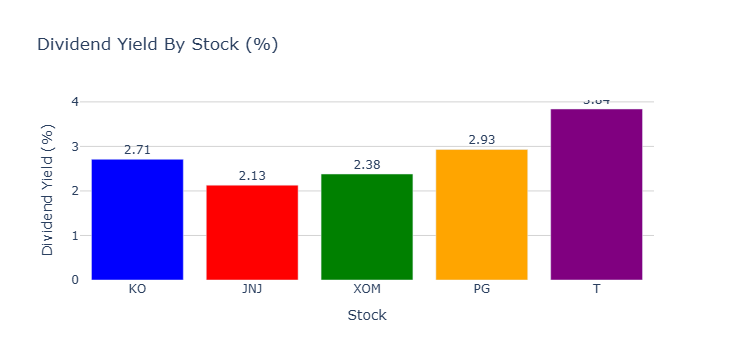

In [9]:
colors =["blue", "red", "green", "orange", "purple"]
fig = go.Figure()
fig.add_trace(go.Bar(
    x=df_yield["ticker"],
    y=df_yield["dividend_yield"],
    marker_color= colors,
    text=df_yield["dividend_yield"],
    textposition="outside"   
))
fig.update_layout(
    title ="Dividend Yield By Stock (%)",
    xaxis_title = "Stock",
    yaxis_title = "Dividend Yield (%)",
    plot_bgcolor="white",
    yaxis=dict(gridcolor="lightgrey")
)
fig.show()

In [10]:
close = data["Close"]
adj_close = data["Adj Close"]
close_norm = (close/close.iloc[0])*100
adj_close_norm = (adj_close/ adj_close.iloc[0])*100
close_norm.head(3)

Ticker,JNJ,KO,PG,T,XOM
Date,,,,,
2015-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2015-01-05,99.301573,100.000000,99.524546,99.055205,97.263815
2015-01-06,98.813626,100.759373,99.071203,99.202832,96.746737


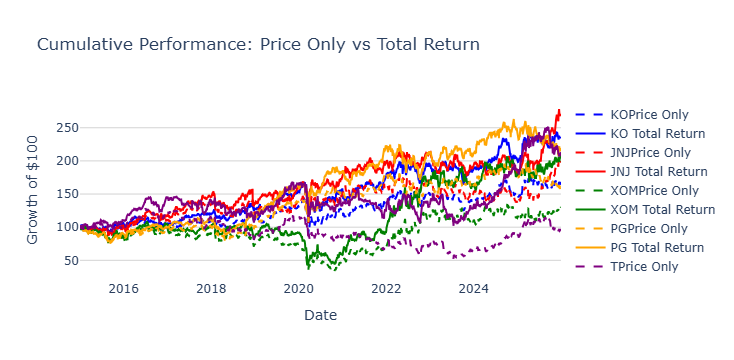

In [11]:
fig = go.Figure()

for i, ticker in enumerate(tickers):
     fig.add_trace(go.Scatter(
         x=close_norm.index,
         y=close_norm[ticker],
         name=ticker + "Price Only",
         line=dict(color=colors[i], dash="dash")
     ))
     
     fig.add_trace(go.Scatter(
         x=adj_close_norm.index,
         y=adj_close_norm[ticker],
         name=ticker + " Total Return",
         line=dict(color=colors[i], dash="solid")
     ))
fig.update_layout(
         title="Cumulative Performance: Price Only vs Total Return",
         xaxis_title="Date",
         yaxis_title="Growth of $100",
         plot_bgcolor="white",
         yaxis=dict(gridcolor="lightgrey")
)
    
fig.show()
     

In [12]:
adj_close = data["Adj Close"]
print(adj_close)

Ticker             JNJ         KO          PG          T         XOM
Date                                                                
2015-01-02   76.548637  29.580021   66.049393  11.522749   57.533417
2015-01-05   76.013992  29.580021   65.735352  11.413885   55.959198
2015-01-06   75.640472  29.804630   65.435913  11.430894   55.661724
2015-01-07   77.310287  30.176680   65.779167  11.497542   56.225708
2015-01-08   77.918190  30.541676   66.531395  11.611932   57.161572
...                ...        ...         ...        ...         ...
2025-12-24  206.681259  69.631218  143.471359  24.374235  118.430618
2025-12-26  206.532059  69.392860  143.719589  24.364351  118.321342
2025-12-29  206.462418  69.680878  143.550797  24.482962  119.731941
2025-12-30  205.815857  69.591492  143.034454  24.522497  120.188896
2025-12-31  205.855652  69.432587  142.299667  24.552151  119.543198

[2766 rows x 5 columns]


In [13]:
returns = adj_close.pct_change().dropna()
corr_matrix = returns.corr()
print("Correlation matrix: \n" + str(corr_matrix.round(2)))

Correlation matrix: 
Ticker   JNJ    KO    PG     T   XOM
Ticker                              
JNJ     1.00  0.50  0.53  0.39  0.31
KO      0.50  1.00  0.62  0.47  0.37
PG      0.53  0.62  1.00  0.41  0.25
T       0.39  0.47  0.41  1.00  0.37
XOM     0.31  0.37  0.25  0.37  1.00


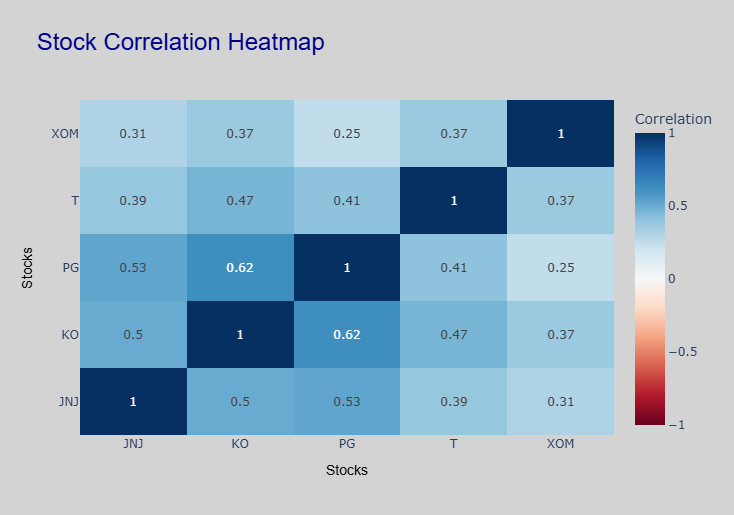

In [14]:
fig = go.Figure()

fig.add_trace(go.Heatmap(
    z=corr_matrix.values,
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.columns.tolist(),
    colorscale="RdBu",
    zmin=-1,
    zmax=1,
    text=corr_matrix.round(2).values,
    texttemplate="%{text}",
    showscale=True,
    colorbar=dict(title="Correlation")
))

fig.update_layout(
    title=dict(
        text="Stock Correlation Heatmap",
        font=dict(size=24, color="darkblue", family= "Arial")
    ),
    xaxis_title=dict(
        text="Stocks",
        font=dict(size=14, color="black", family="Arial")
    ),
    yaxis_title =dict(
        text="Stocks",
        font=dict(size=14, color="black", family="Arial")
    ),
    plot_bgcolor= "white",
    paper_bgcolor="lightgrey",
    width=1000,
    height=500
)
fig.show()


In [18]:
import numpy as np
risk_free_rate = 0.0369

num_portfolios = 10000
num_stocks = len(tickers)

port_returns = []
port_volatility = []
port_sharpe = []
port_weights = []

mean_returns = returns.mean()*252
cov_matrix = returns.cov()*252

In [19]:
for _ in range(num_portfolios):
    weights = np.random.random(num_stocks)
    weights = weights / np.sum(weights)

    ret = np.dot(weights, mean_returns)
    vol = np.sqrt(np.dot(weights.T,np.dot(cov_matrix, weights)))
    sharpe = (ret - risk_free_rate) / vol

    port_returns.append(ret)
    port_volatility.append(vol)
    port_sharpe.append(sharpe)
    port_weights.append(weights)

In [20]:
portfolio_df = pd.DataFrame({
    "Return": port_returns,
    "Volatility": port_volatility,
    "Sharpe": port_sharpe
})
print(portfolio_df.head())

     Return  Volatility    Sharpe
0  0.097441    0.153746  0.393774
1  0.099952    0.164007  0.384450
2  0.098549    0.152034  0.405493
3  0.096490    0.156692  0.380303
4  0.098202    0.152463  0.402074


In [24]:
max_sharpe_idx = portfolio_df["Sharpe"].idxmax()
min_vol_idx = portfolio_df["Volatility"].idxmin()

max_sharpe_port = portfolio_df.loc[max_sharpe_idx]
min_vol_port = portfolio_df.loc[min_vol_idx]

print("Max Sharpe Portfolio:\n",max_sharpe_port)
print("\nMin Variance Portfolio:\n",min_vol_port)

Max Sharpe Portfolio:
 Return        0.100858
Volatility    0.150863
Sharpe        0.423946
Name: 5156, dtype: float64

Min Variance Portfolio:
 Return        0.096909
Volatility    0.147425
Sharpe        0.407047
Name: 3913, dtype: float64


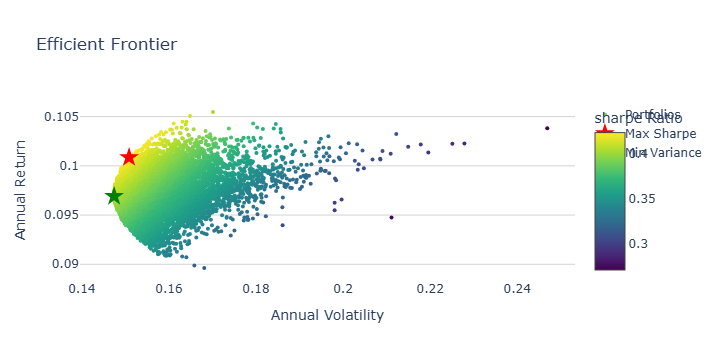

In [26]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=portfolio_df["Volatility"],
    y=portfolio_df["Return"],
    mode="markers",
    marker=dict(
        color=portfolio_df["Sharpe"],
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="sharpe Ratio"),
        size=4
    ),
    name="Portfolios"
))
#Trace 2 = Max Sharpe
fig.add_trace(go.Scatter(
    x=[max_sharpe_port["Volatility"]],
    y=[max_sharpe_port["Return"]],
    mode="markers",
    marker=dict(color="red", size=15, symbol="star"),
    name="Max Sharpe"
))

#Trace 3 = Min Variance
fig.add_trace(go.Scatter(
    x=[min_vol_port["Volatility"]],
    y=[min_vol_port["Return"]],
    mode="markers",
    marker=dict(color="green", size=15, symbol="star"),
    name="Min Variance"
))
fig.update_layout(
    title="Efficient Frontier",
    xaxis_title="Annual Volatility",
    yaxis_title="Annual Return",
    plot_bgcolor="white",
    yaxis=dict(gridcolor="lightgrey")
)
fig.show()
    
    

In [27]:
weight_df = pd.DataFrame(port_weights, columns=tickers)
portfolio_df = pd.concat([portfolio_df,weight_df],axis=1)
print(portfolio_df.head())

     Return  Volatility    Sharpe        KO       JNJ       XOM        PG  \
0  0.097441    0.153746  0.393774  0.247372  0.189678  0.132204  0.328860   
1  0.099952    0.164007  0.384450  0.228146  0.272617  0.089771  0.045307   
2  0.098549    0.152034  0.405493  0.243564  0.338983  0.075369  0.148147   
3  0.096490    0.156692  0.380303  0.183695  0.006230  0.339105  0.244106   
4  0.098202    0.152463  0.402074  0.272819  0.145917  0.256970  0.080776   

          T  
0  0.101885  
1  0.364159  
2  0.193937  
3  0.226865  
4  0.243519  


In [28]:
max_sharpe_port = portfolio_df.loc[max_sharpe_idx]
min_vol_port= portfolio_df.loc[min_vol_idx]

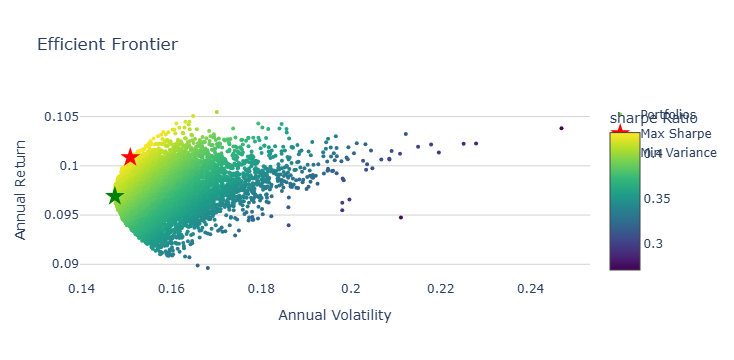

In [30]:
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=portfolio_df["Volatility"],
    y=portfolio_df["Return"],
    mode="markers",
    marker=dict(
        color=portfolio_df["Sharpe"],
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="sharpe Ratio"),
        size=4
    ),
    customdata=portfolio_df[tickers].values,
    hovertemplate="Return: %{y:.2%}<br>Volatility: %{x:.2%}<br>KO: %{customdata[0]:.2%}<br>JNJ: %{customdata[1]:.2%}<br>XOM: %{customdata[2]:.2%}<br>PG: %{customdata[3]:.2%}<br>T: %{customdata[4]:.2%}",
    name="Portfolios"
))
#Trace 2 = Max Sharpe
fig.add_trace(go.Scatter(
    x=[max_sharpe_port["Volatility"]],
    y=[max_sharpe_port["Return"]],
    mode="markers",
    marker=dict(color="red", size=15, symbol="star"),
    name="Max Sharpe",
    customdata=[max_sharpe_port[tickers].values],
    hovertemplate="Return: %{y:.2%}<br>Volatility: %{x:.2%}<br>KO: %{customdata[0]:.2%}<br>JNJ: %{customdata[1]:.2%}<br>XOM: %{customdata[2]:.2%}<br>PG: %{customdata[3]:.2%}<br>T: %{customdata[4]:.2%}",    
))

#Trace 3 = Min Variance
fig.add_trace(go.Scatter(
    x=[min_vol_port["Volatility"]],
    y=[min_vol_port["Return"]],
    mode="markers",
    marker=dict(color="green", size=15, symbol="star"),
    name="Min Variance",
    customdata=[min_vol_port[tickers].values],
    hovertemplate="Return: %{y:.2%}<br>Volatility: %{x:.2%}<br>KO: %{customdata[0]:.2%}<br>JNJ: %{customdata[1]:.2%}<br>XOM: %{customdata[2]:.2%}<br>PG: %{customdata[3]:.2%}<br>T: %{customdata[4]:.2%}",    
))
fig.update_layout(
    title="Efficient Frontier",
    xaxis_title="Annual Volatility",
    yaxis_title="Annual Return",
    plot_bgcolor="white",
    yaxis=dict(gridcolor="lightgrey")
)
fig.show()